In [1]:
# ============================================================
# CELL 1: Imports and Load Clean Data
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load the clean data we saved in Phase 1
df = pd.read_csv(
    '../data/processed/clean_transactions.csv',
    parse_dates=['InvoiceDate'],
    dtype={'Customer ID': str}
)

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}")
df.head(3)

Loaded: 779,425 rows × 9 columns
Date range: 2009-12-01 → 2011-12-09


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0


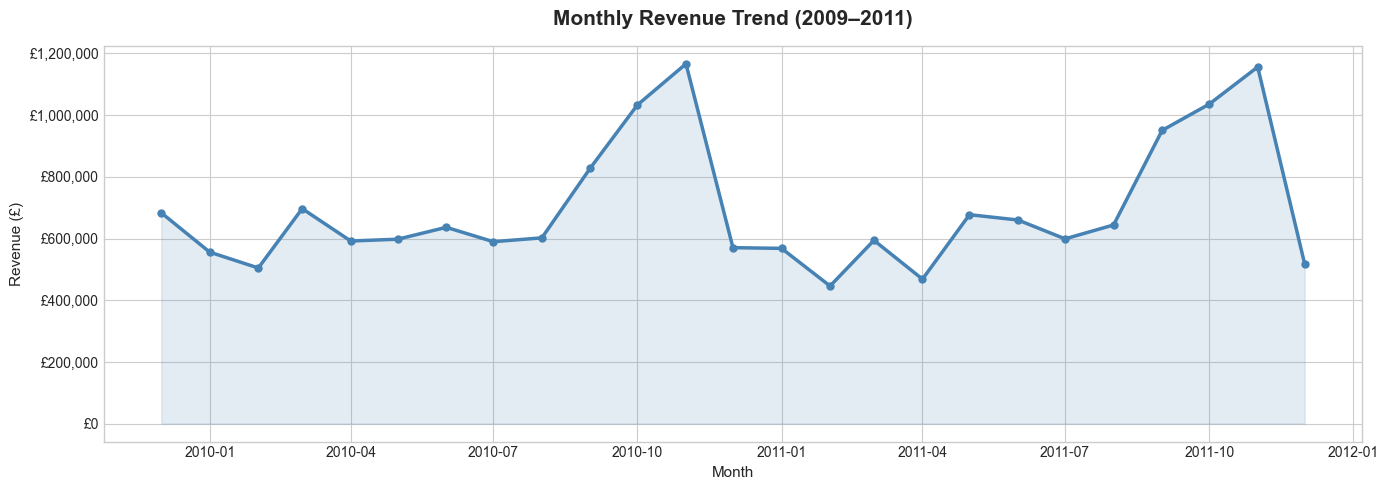

Saved: reports/figures/01_monthly_revenue.png

Peak month:   2010-11
Peak revenue: £1,166,460
Avg monthly:  £694,992


In [2]:
# ============================================================
# CELL 2: Revenue Trend Over Time
# ============================================================
# Why: Reveals seasonality, growth trends, anomalies
# This is the first question any business stakeholder asks:
# "How is revenue trending?"

os.makedirs('../reports/figures', exist_ok=True)

# Aggregate revenue by month
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()
monthly_revenue['YearMonth_dt'] = monthly_revenue['YearMonth'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    monthly_revenue['YearMonth_dt'],
    monthly_revenue['TotalPrice'],
    color='steelblue', linewidth=2.5, marker='o', markersize=5
)
ax.fill_between(
    monthly_revenue['YearMonth_dt'],
    monthly_revenue['TotalPrice'],
    alpha=0.15, color='steelblue'
)

ax.set_title('Monthly Revenue Trend (2009–2011)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Revenue (£)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

plt.tight_layout()
plt.savefig('../reports/figures/01_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/figures/01_monthly_revenue.png")

# Print key stats
print(f"\nPeak month:   {monthly_revenue.loc[monthly_revenue['TotalPrice'].idxmax(), 'YearMonth']}")
print(f"Peak revenue: £{monthly_revenue['TotalPrice'].max():,.0f}")
print(f"Avg monthly:  £{monthly_revenue['TotalPrice'].mean():,.0f}")

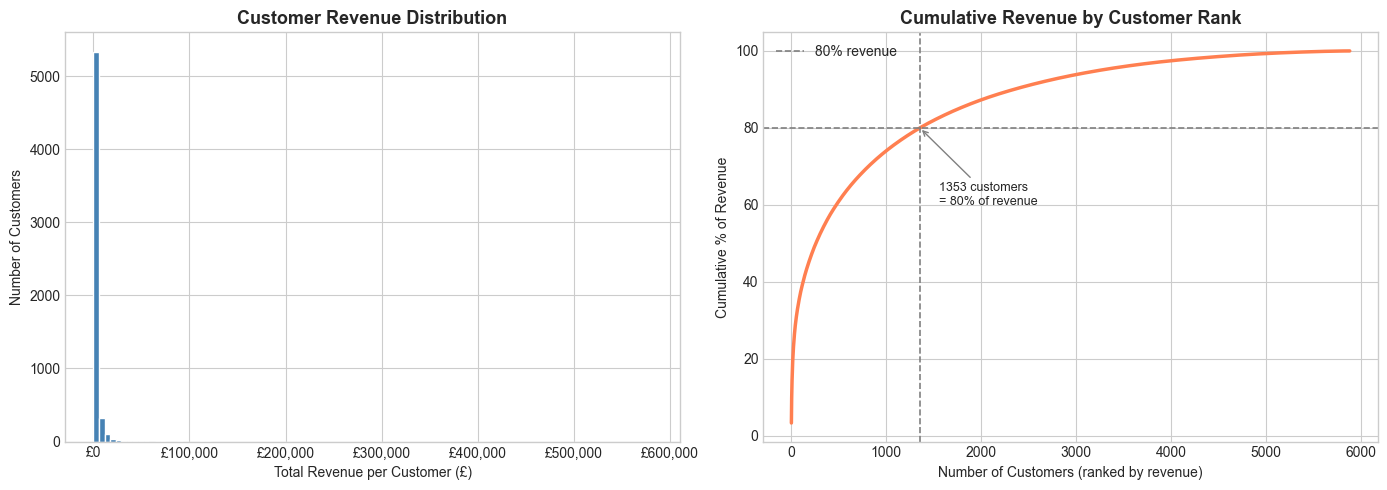

Top 1353 customers (23.0%) generate 80% of revenue

Top 10 customers by revenue:
Customer ID
18102    £580,987
14646    £528,603
14156    £313,438
14911    £291,421
17450    £244,784
13694    £195,641
17511    £172,133
16446    £168,472
16684    £147,143
12415    £144,458
Name: TotalPrice, dtype: object


In [3]:
# ============================================================
# CELL 3: Customer Revenue Distribution — The Pareto Principle
# ============================================================
# Why: Almost every retail dataset follows the 80/20 rule
# (80% of revenue from 20% of customers)
# This directly motivates WHY we do customer segmentation

customer_revenue = df.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False)
customer_revenue_pct = customer_revenue.cumsum() / customer_revenue.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Revenue distribution
axes[0].hist(customer_revenue, bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Customer Revenue Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Revenue per Customer (£)')
axes[0].set_ylabel('Number of Customers')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

# Right: Pareto curve
axes[1].plot(
    range(1, len(customer_revenue_pct) + 1),
    customer_revenue_pct.values,
    color='coral', linewidth=2.5
)
axes[1].axhline(y=80, color='gray', linestyle='--', linewidth=1.2, label='80% revenue')
axes[1].set_title('Cumulative Revenue by Customer Rank', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Customers (ranked by revenue)')
axes[1].set_ylabel('Cumulative % of Revenue')
axes[1].legend()

# Find how many customers = 80% of revenue
top_customers_80 = (customer_revenue_pct <= 80).sum()
axes[1].axvline(x=top_customers_80, color='gray', linestyle='--', linewidth=1.2)
axes[1].annotate(
    f'{top_customers_80} customers\n= 80% of revenue',
    xy=(top_customers_80, 80),
    xytext=(top_customers_80 + 200, 60),
    fontsize=9,
    arrowprops=dict(arrowstyle='->', color='gray')
)

plt.tight_layout()
plt.savefig('../reports/figures/02_pareto_curve.png', dpi=150, bbox_inches='tight')
plt.show()

pct_customers = top_customers_80 / len(customer_revenue) * 100
print(f"Top {top_customers_80} customers ({pct_customers:.1f}%) generate 80% of revenue")
print(f"\nTop 10 customers by revenue:")
print(customer_revenue.head(10).apply(lambda x: f'£{x:,.0f}'))

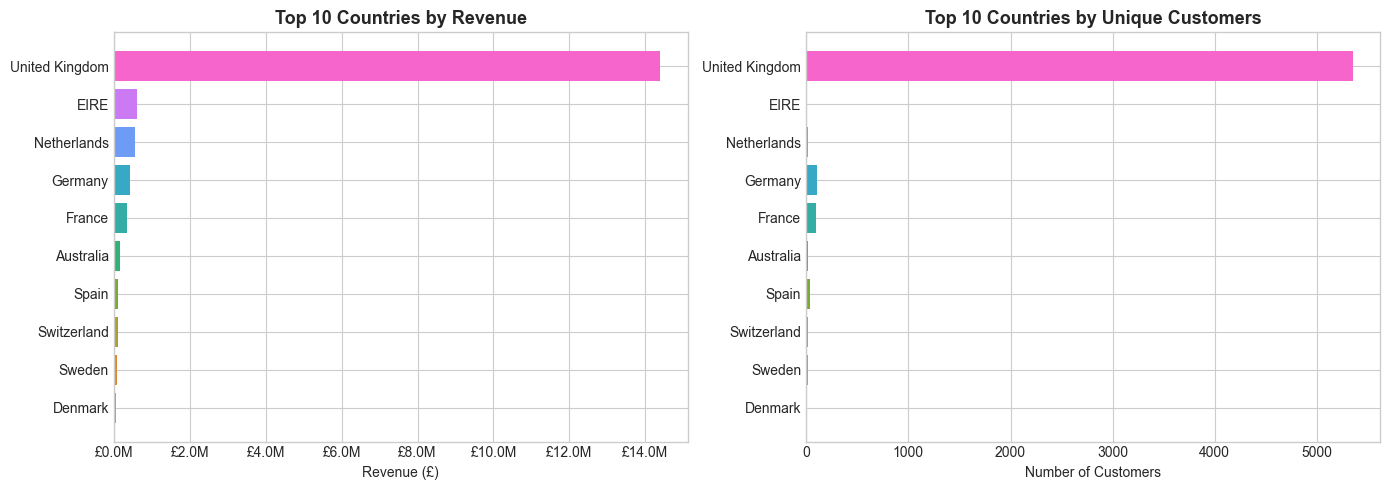


Top 10 Countries — Full Summary:
                    Revenue  Customers  Orders Avg_Order_Value
Country                                                       
United Kingdom  £14,389,235       5350   33541            £429
EIRE               £616,571          5     567          £1,087
Netherlands        £554,038         22     228          £2,430
Germany            £425,020        107     789            £539
France             £348,769         95     614            £568
Australia          £169,283         15      95          £1,782
Spain              £108,332         41     154            £703
Switzerland        £100,062         22      90          £1,112
Sweden              £91,516         19     104            £880
Denmark             £68,581         12      43          £1,595


In [4]:
# ============================================================
# CELL 4: Revenue by Country
# ============================================================
# Why: Tells us if we need country-specific models or if one
# model for all countries is appropriate

country_revenue = df.groupby('Country').agg(
    Revenue=('TotalPrice', 'sum'),
    Customers=('Customer ID', 'nunique'),
    Orders=('Invoice', 'nunique')
).sort_values('Revenue', ascending=False).head(10)

country_revenue['Avg_Order_Value'] = country_revenue['Revenue'] / country_revenue['Orders']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Revenue by country
bars = axes[0].barh(
    country_revenue.index[::-1],
    country_revenue['Revenue'][::-1],
    color=sns.color_palette("husl", 10)
)
axes[0].set_title('Top 10 Countries by Revenue', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Revenue (£)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))

# Right: Customers by country
axes[1].barh(
    country_revenue.index[::-1],
    country_revenue['Customers'][::-1],
    color=sns.color_palette("husl", 10)
)
axes[1].set_title('Top 10 Countries by Unique Customers', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Customers')

plt.tight_layout()
plt.savefig('../reports/figures/03_country_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 Countries — Full Summary:")
country_revenue['Revenue'] = country_revenue['Revenue'].apply(lambda x: f'£{x:,.0f}')
country_revenue['Avg_Order_Value'] = country_revenue['Avg_Order_Value'].apply(lambda x: f'£{x:,.0f}')
print(country_revenue.to_string())

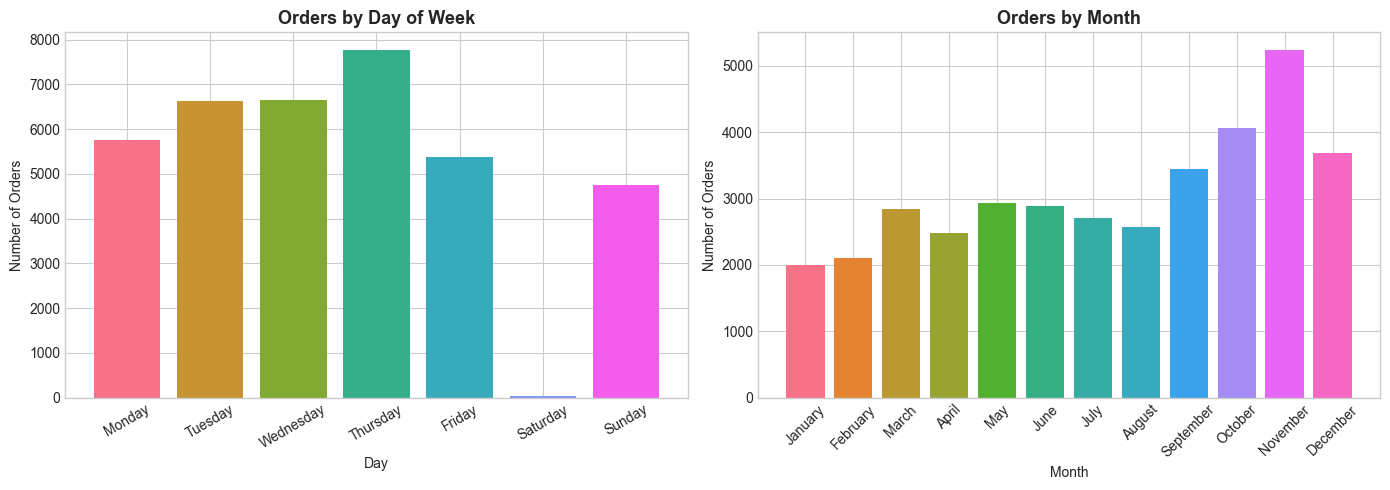

Busiest day:   Thursday (7,773 orders)
Quietest day:  Saturday (30 orders)
Busiest month: November (5,244 orders)


In [5]:
# ============================================================
# CELL 5: Seasonality — Day of Week and Hour of Day
# ============================================================
# Why: Behavioral patterns by time are powerful features
# for both segmentation and churn prediction

df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour
df['Month'] = df['InvoiceDate'].dt.month_name()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Orders by day of week
day_orders = df.groupby('DayOfWeek')['Invoice'].nunique().reindex(day_order)
axes[0].bar(day_order, day_orders.values, color=sns.color_palette("husl", 7))
axes[0].set_title('Orders by Day of Week', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=30)

# Orders by month
month_orders = df.groupby('Month')['Invoice'].nunique().reindex(month_order)
axes[1].bar(month_order, month_orders.values, color=sns.color_palette("husl", 12))
axes[1].set_title('Orders by Month', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/04_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Busiest day:   {day_orders.idxmax()} ({day_orders.max():,} orders)")
print(f"Quietest day:  {day_orders.idxmin()} ({day_orders.min():,} orders)")
print(f"Busiest month: {month_orders.idxmax()} ({month_orders.max():,} orders)")

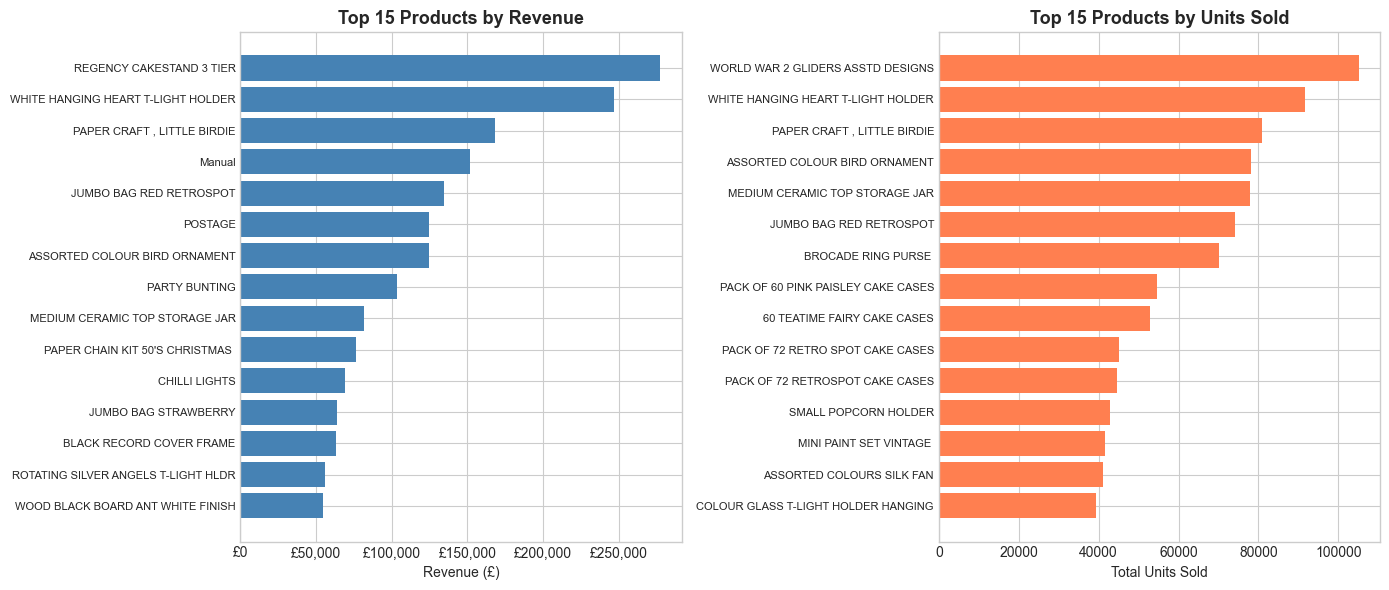

Top 5 products by revenue:
  REGENCY CAKESTAND 3 TIER                 £   277,656
  WHITE HANGING HEART T-LIGHT HOLDER       £   247,048
  PAPER CRAFT , LITTLE BIRDIE              £   168,470
  Manual                                   £   151,778
  JUMBO BAG RED RETROSPOT                  £   134,307


In [6]:
# ============================================================
# CELL 6: Top Products by Revenue and Volume
# ============================================================
# Why: Reveals what drives the business and can be used
# as product-affinity features in segmentation

product_stats = df.groupby('Description').agg(
    Revenue=('TotalPrice', 'sum'),
    Quantity=('Quantity', 'sum'),
    Orders=('Invoice', 'nunique')
).sort_values('Revenue', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top by revenue
axes[0].barh(
    product_stats['Revenue'].index[::-1],
    product_stats['Revenue'].values[::-1],
    color='steelblue'
)
axes[0].set_title('Top 15 Products by Revenue', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Revenue (£)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[0].tick_params(axis='y', labelsize=8)

# Top by quantity
product_qty = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(15)
axes[1].barh(
    product_qty.index[::-1],
    product_qty.values[::-1],
    color='coral'
)
axes[1].set_title('Top 15 Products by Units Sold', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Units Sold')
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/05_top_products.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 products by revenue:")
for desc, row in product_stats.head(5).iterrows():
    print(f"  {desc[:40]:<40} £{row['Revenue']:>10,.0f}")

In [7]:
# ============================================================
# CELL 7: EDA Summary — Key Business Insights
# ============================================================
# This is what you say in interviews and write in your README

print("=" * 60)
print("EDA KEY FINDINGS")
print("=" * 60)

uk_revenue = df[df['Country'] == 'United Kingdom']['TotalPrice'].sum()
total_revenue = df['TotalPrice'].sum()
uk_pct = uk_revenue / total_revenue * 100

print(f"""
BUSINESS OVERVIEW
-----------------
Total Revenue:        £{total_revenue:>12,.0f}
Total Transactions:   {df['Invoice'].nunique():>12,}
Total Customers:      {df['Customer ID'].nunique():>12,}
Total Products:       {df['StockCode'].nunique():>12,}
Date Range:           {df['InvoiceDate'].min().date()} → {df['InvoiceDate'].max().date()}

GEOGRAPHIC CONCENTRATION
------------------------
UK Revenue Share:     {uk_pct:>11.1f}%
Non-UK Customers:     {df[df['Country'] != 'United Kingdom']['Customer ID'].nunique():>12,}

CUSTOMER VALUE
--------------
Avg Revenue/Customer: £{df.groupby('Customer ID')['TotalPrice'].sum().mean():>11,.0f}
Max Revenue/Customer: £{df.groupby('Customer ID')['TotalPrice'].sum().max():>11,.0f}
Median Revenue/Cust:  £{df.groupby('Customer ID')['TotalPrice'].sum().median():>11,.0f}

PARETO CHECK
------------
Top 20% customers drive ~80% of revenue: Classic long-tail distribution
→ This JUSTIFIES customer segmentation as a business priority
""")
print("=" * 60)
print("All EDA figures saved to reports/figures/")

EDA KEY FINDINGS

BUSINESS OVERVIEW
-----------------
Total Revenue:        £  17,374,804
Total Transactions:         36,969
Total Customers:             5,878
Total Products:              4,631
Date Range:           2009-12-01 → 2011-12-09

GEOGRAPHIC CONCENTRATION
------------------------
UK Revenue Share:            82.8%
Non-UK Customers:              529

CUSTOMER VALUE
--------------
Avg Revenue/Customer: £      2,956
Max Revenue/Customer: £    580,987
Median Revenue/Cust:  £        868

PARETO CHECK
------------
Top 20% customers drive ~80% of revenue: Classic long-tail distribution
→ This JUSTIFIES customer segmentation as a business priority

All EDA figures saved to reports/figures/
